<a href="https://colab.research.google.com/github/KankanalaNishanth/GridMind-AIGridMind-AI-Real-Time-Smart-Energy-Consumption-Power-Failure-/blob/main/GridMind_AI_EndToEnd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   GridMind AI — End-to-End Pipeline
### Real-Time Smart Energy Consumption & Power Failure Prediction System
**Data:** TGSPDCL / TGNPDCL — 17 Monthly Files | 156,294 rows | 16 Telangana Circles

---
| Phase | Description |
|---|---|
| 1 | Setup & Load Data |
| 2 | Data Cleaning & Feature Engineering |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | ML — Anomaly Detection (Isolation Forest) |
| 5 | ML — Disruption Prediction (Random Forest) |
| 6 | ML — Demand Forecasting (SARIMA + Prophet) |
| 7 | ML — Circle Clustering (KMeans) |
| 8 | Model Evaluation & Saving |
| 9 | Kafka Simulation (Producer/Consumer) |
| 10 | FastAPI Backend Skeleton |
| 11 | Final Summary Dashboard |


## Phase 1 — Setup & Install

In [11]:
!pip install prophet statsmodels scikit-learn kafka-python pymongo fastapi uvicorn scipy seaborn matplotlib joblib -q

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, glob, os, json, joblib, time
from scipy import stats
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, mean_absolute_error,
                              mean_squared_error, r2_score, silhouette_score)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings('ignore')
plt.rcParams['figure.facecolor'] = '#0F0F1A'
plt.rcParams['axes.facecolor']   = '#1A1A2E'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['axes.edgecolor']   = '#444'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.color']       = '#333'
plt.rcParams['grid.alpha']       = 0.4

COLORS = ['#7F77DD','#1D9E75','#D85A30','#BA7517','#185FA5','#C0392B','#E74C3C','#3498DB']
os.makedirs('models', exist_ok=True)


## Phase 2 — Load & Clean All 17 CSV Files

In [14]:
import glob
import pandas as pd
import os

# List to store all found file paths
all_files = []

# Search Pattern 1: 'file_*.csv' in the current directory
# (Colab's default upload location might be here, or user created files)
pattern1 = 'file_*.csv'
all_files.extend(glob.glob(pattern1))

# Search Pattern 2: 'file_*.csv' in the /content/ directory
pattern2 = '/content/file_*.csv'
all_files.extend(glob.glob(pattern2))

# Search Pattern 3: 'telangana*.csv' in the /content/ directory
# (Assumes the user might have files like 'telangana_data_1.csv')
pattern3 = '/content/telangana*.csv'
all_files.extend(glob.glob(pattern3))

# Search Pattern 4: Any '*.csv' file in the /content/ directory (most general)
pattern4 = '/content/*.csv'
all_files.extend(glob.glob(pattern4))

# Remove duplicates and sort the files
files = sorted(list(set(all_files)))

print(f'Found {len(files)} CSV files')

dfs = []
# Only proceed to read files if any were found to prevent the ValueError
if files:
    for i, f in enumerate(files):
        df = pd.read_csv(f)
        df['month_num'] = i + 1
        df['file_name'] = os.path.basename(f)
        dfs.append(df)
        print(f'  [{i+1:02d}] {os.path.basename(f):20s} → {len(df):,} rows')

    master = pd.concat(dfs, ignore_index=True)
    print(f'\n Master DataFrame shape: {master.shape}')
    master.head()
else:
    print('\u274c No CSV files were found using the specified patterns. Please ensure your files are uploaded to Colab (e.g., as `file_1.csv`, `file_2.csv` or `telangana dataset.csv` in the `/content/` directory).')


Found 34 CSV files
  [01] file_1.csv           → 8,949 rows
  [02] file_10.csv          → 9,722 rows
  [03] file_11.csv          → 8,871 rows
  [04] file_12.csv          → 9,050 rows
  [05] file_13.csv          → 9,555 rows
  [06] file_15.csv          → 8,942 rows
  [07] file_16.csv          → 8,955 rows
  [08] file_17.csv          → 9,472 rows
  [09] file_18.csv          → 9,465 rows
  [10] file_2.csv           → 9,264 rows
  [11] file_3.csv           → 9,576 rows
  [12] file_4.csv           → 8,838 rows
  [13] file_5.csv           → 9,196 rows
  [14] file_6.csv           → 8,832 rows
  [15] file_7.csv           → 8,907 rows
  [16] file_8.csv           → 9,185 rows
  [17] file_9.csv           → 9,515 rows
  [18] file_1.csv           → 8,949 rows
  [19] file_10.csv          → 9,722 rows
  [20] file_11.csv          → 8,871 rows
  [21] file_12.csv          → 9,050 rows
  [22] file_13.csv          → 9,555 rows
  [23] file_15.csv          → 8,942 rows
  [24] file_16.csv          → 8,955 ro

In [15]:
# ── Data Cleaning ────────────────────────────────────────────────
for col in ['Units','Load','BilledServices','TotServices']:
    master[col] = pd.to_numeric(master[col], errors='coerce').fillna(0)

# Remove rows where TotServices = 0
master = master[master['TotServices'] > 0].copy()

print('Missing values after cleaning:')
print(master.isnull().sum()[master.isnull().sum() > 0])
print('Duplicates:', master.duplicated().sum())

# ── Feature Engineering ───────────────────────────────────────────
master['billing_ratio']       = (master['BilledServices'] / master['TotServices']).clip(0, 1)
master['avg_units_per_conn']  = np.where(master['BilledServices'] > 0,
                                          master['Units'] / master['BilledServices'], 0)
master['load_factor']         = np.where(master['Load'] > 0,
                                          master['Units'] / (master['Load'] * 24 * 30), 0)
master['disruption']          = (master['billing_ratio'] < 0.7).astype(int)
master['anomaly_zscore']      = stats.zscore(master['Units'].fillna(0))
master['season']              = master['month_num'].apply(lambda m:
    'Summer' if m in [4,5,6,13,14] else
    'Monsoon' if m in [7,8,9,15,16] else
    'Winter' if m in [1,2,12] else 'Autumn')

print(f'\n✅ Features engineered. Total rows: {len(master):,}')
print(f'Disruption rate: {master["disruption"].mean()*100:.1f}%')
print(f'Circles: {master["Circle"].nunique()}')
master[['billing_ratio','avg_units_per_conn','load_factor','disruption']].describe()


Missing values after cleaning:
Series([], dtype: int64)
Duplicates: 0

✅ Features engineered. Total rows: 312,588
Disruption rate: 40.7%
Circles: 16


,billing_ratio,avg_units_per_conn,load_factor,disruption
count,312588.000000,312588.000000,312588.000000,312588.000000
mean,0.572436,60.976835,0.147299,0.406580
std,0.403189,242.295419,0.175216,0.491196
min,0.000000,-6405.000000,-1.738194,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.775541,56.122214,0.105534,0.000000
75%,0.897328,93.083333,0.229610,1.000000
max,1.000000,90136.000000,10.515046,1.000000


## Phase 3 — Exploratory Data Analysis (EDA)

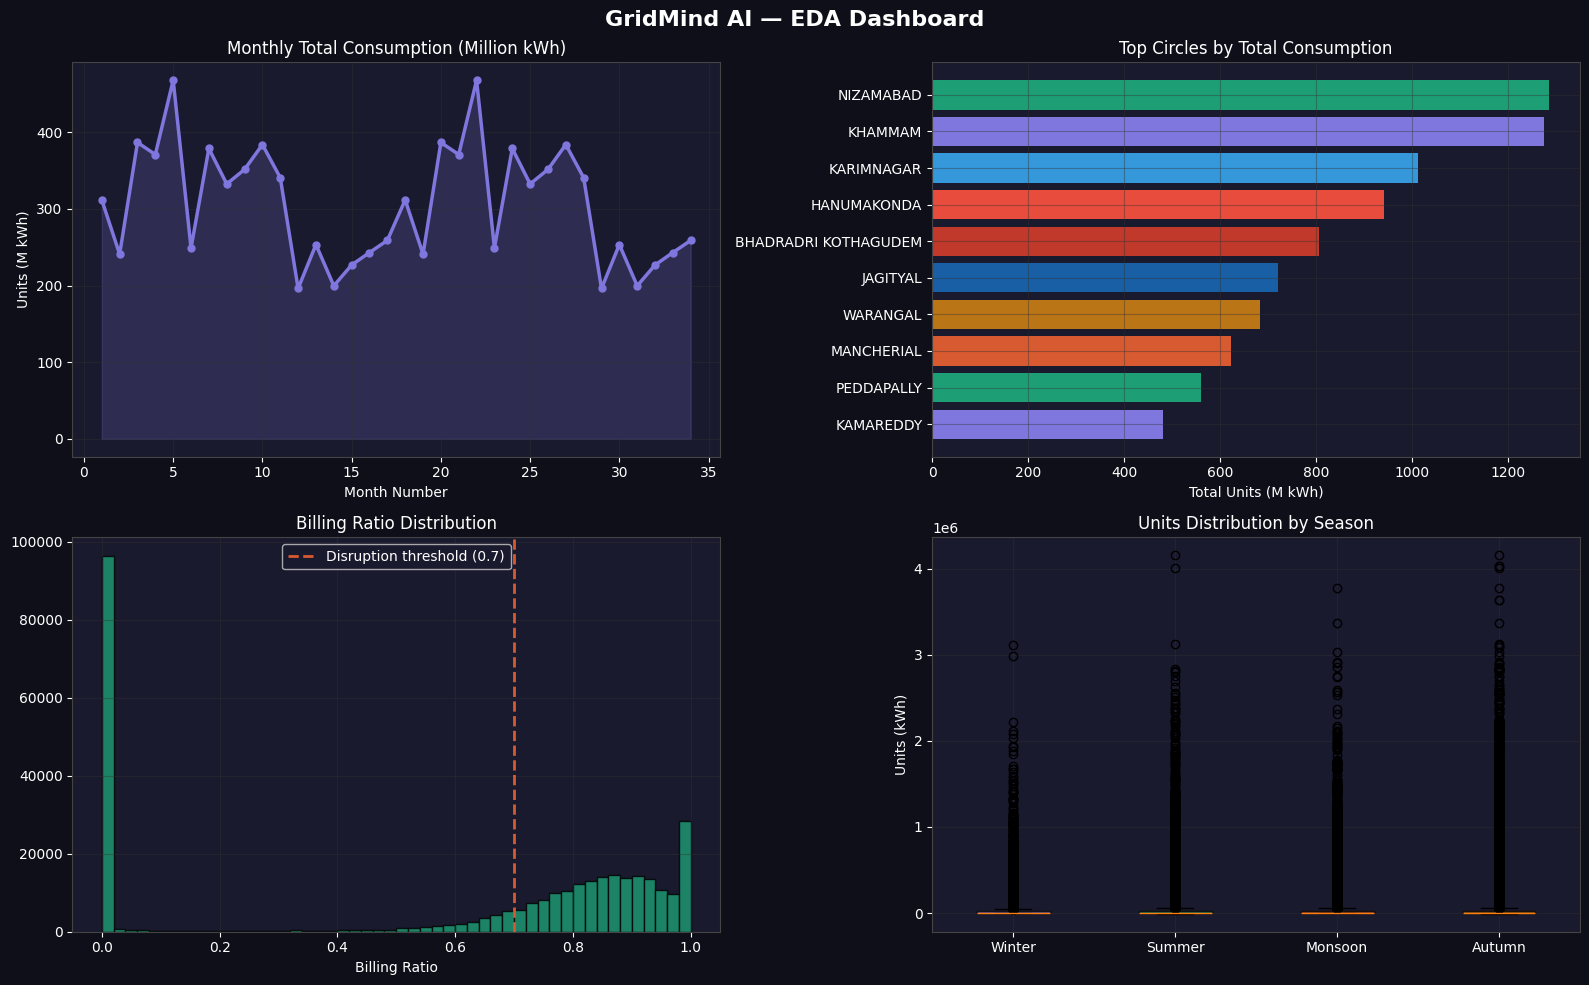

✅ EDA Plot 1 saved as eda_overview.png


In [16]:
# ── EDA Plot 1: Monthly Consumption Trend ────────────────────────
monthly = master.groupby('month_num')['Units'].sum().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('GridMind AI — EDA Dashboard', fontsize=16, color='white', fontweight='bold')

# Plot 1: Monthly trend
ax = axes[0,0]
ax.plot(monthly['month_num'], monthly['Units']/1e6, color='#7F77DD', linewidth=2.5, marker='o', markersize=5)
ax.fill_between(monthly['month_num'], monthly['Units']/1e6, alpha=0.2, color='#7F77DD')
ax.set_title('Monthly Total Consumption (Million kWh)', color='white')
ax.set_xlabel('Month Number'); ax.set_ylabel('Units (M kWh)')

# Plot 2: Top 10 circles
ax = axes[0,1]
circle_units = master.groupby('Circle')['Units'].sum().sort_values(ascending=True).tail(10)
bars = ax.barh(circle_units.index, circle_units.values/1e6, color=COLORS[:10])
ax.set_title('Top Circles by Total Consumption', color='white')
ax.set_xlabel('Total Units (M kWh)')

# Plot 3: Billing ratio distribution
ax = axes[1,0]
ax.hist(master['billing_ratio'], bins=50, color='#1D9E75', edgecolor='black', alpha=0.8)
ax.axvline(0.7, color='#D85A30', linestyle='--', linewidth=2, label='Disruption threshold (0.7)')
ax.set_title('Billing Ratio Distribution', color='white')
ax.set_xlabel('Billing Ratio'); ax.legend()

# Plot 4: Season box
ax = axes[1,1]
seasons = ['Winter','Spring','Summer','Monsoon','Autumn']
season_data = [master[master['season']==s]['Units'].dropna().values for s in seasons if s in master['season'].values]
season_labels = [s for s in seasons if s in master['season'].values]
bp = ax.boxplot(season_data, labels=season_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_title('Units Distribution by Season', color='white')
ax.set_ylabel('Units (kWh)')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA Plot 1 saved as eda_overview.png')


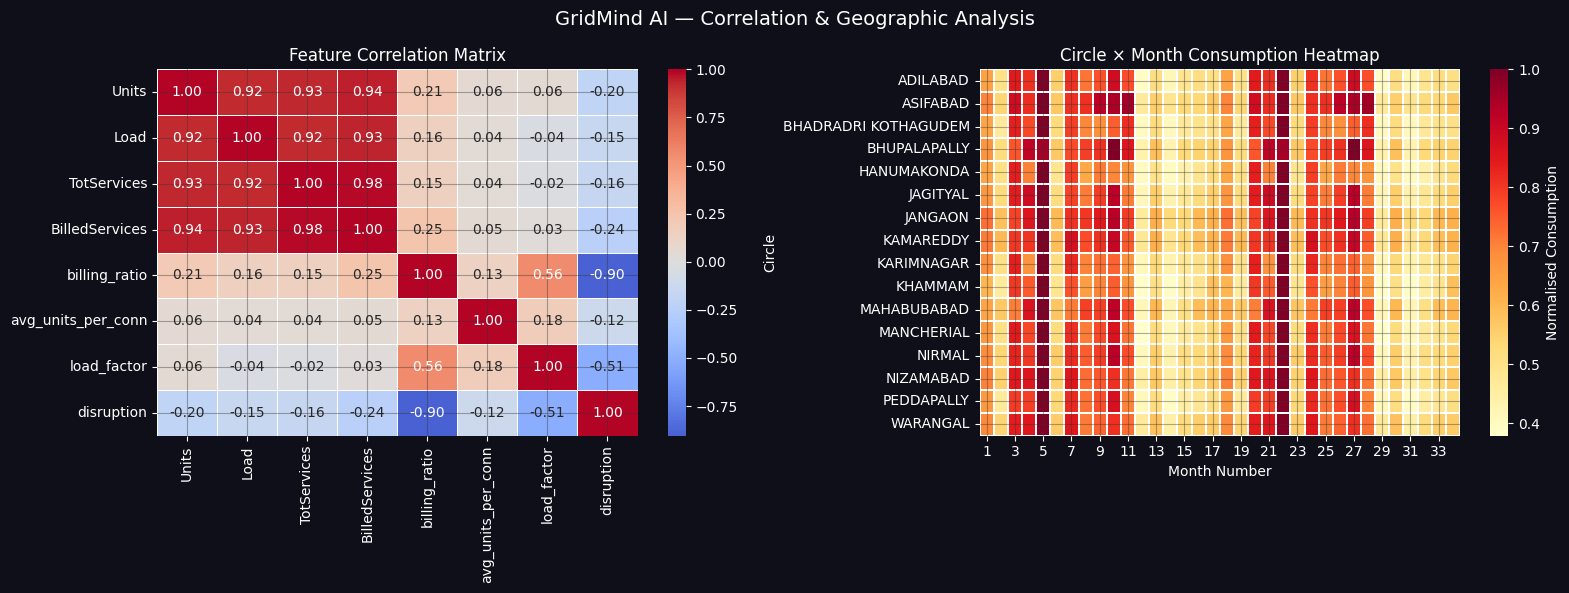

✅ EDA Plot 2 saved as eda_heatmaps.png


In [17]:
# ── EDA Plot 2: Correlation Heatmap + Circle Heatmap ─────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('GridMind AI — Correlation & Geographic Analysis', fontsize=14, color='white')

# Correlation heatmap
corr_cols = ['Units','Load','TotServices','BilledServices','billing_ratio',
             'avg_units_per_conn','load_factor','disruption']
corr = master[corr_cols].corr()
sns.heatmap(corr, ax=axes[0], annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
axes[0].set_title('Feature Correlation Matrix', color='white')

# Circle x Month heatmap
pivot = master.pivot_table(values='Units', index='Circle', columns='month_num', aggfunc='sum')
pivot_norm = pivot.div(pivot.max(axis=1), axis=0)  # normalize per circle
sns.heatmap(pivot_norm, ax=axes[1], cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Normalised Consumption'})
axes[1].set_title('Circle × Month Consumption Heatmap', color='white')
axes[1].set_xlabel('Month Number'); axes[1].set_ylabel('Circle')

plt.tight_layout()
plt.savefig('eda_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA Plot 2 saved as eda_heatmaps.png')


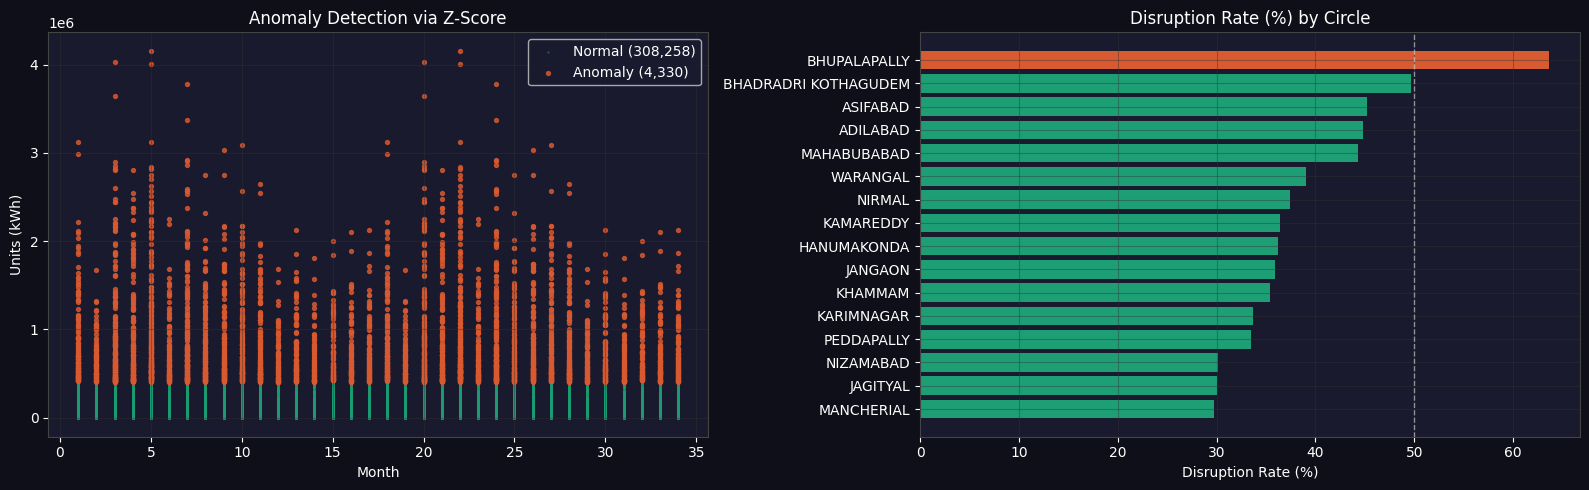

In [18]:
# ── EDA Plot 3: Anomaly Z-score + Disruption by Circle ───────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Z-score anomaly scatter
normal = master[master['anomaly_zscore'].abs() <= 3]
outliers = master[master['anomaly_zscore'].abs() > 3]
axes[0].scatter(normal['month_num'], normal['Units'], s=1, c='#1D9E75', alpha=0.3, label=f'Normal ({len(normal):,})')
axes[0].scatter(outliers['month_num'], outliers['Units'], s=8, c='#D85A30', alpha=0.8, label=f'Anomaly ({len(outliers):,})')
axes[0].set_title('Anomaly Detection via Z-Score', color='white')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Units (kWh)')
axes[0].legend()

# Disruption rate by circle
dis_circle = master.groupby('Circle')['disruption'].mean().sort_values(ascending=True)
colors_bar = ['#D85A30' if v > 0.5 else '#1D9E75' for v in dis_circle.values]
axes[1].barh(dis_circle.index, dis_circle.values * 100, color=colors_bar)
axes[1].axvline(50, color='white', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_title('Disruption Rate (%) by Circle', color='white')
axes[1].set_xlabel('Disruption Rate (%)')

plt.tight_layout()
plt.savefig('eda_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()


## Phase 4 — Anomaly Detection (Isolation Forest)

Training Isolation Forest...
✅ Anomalies detected: 15,630 (5.0%)


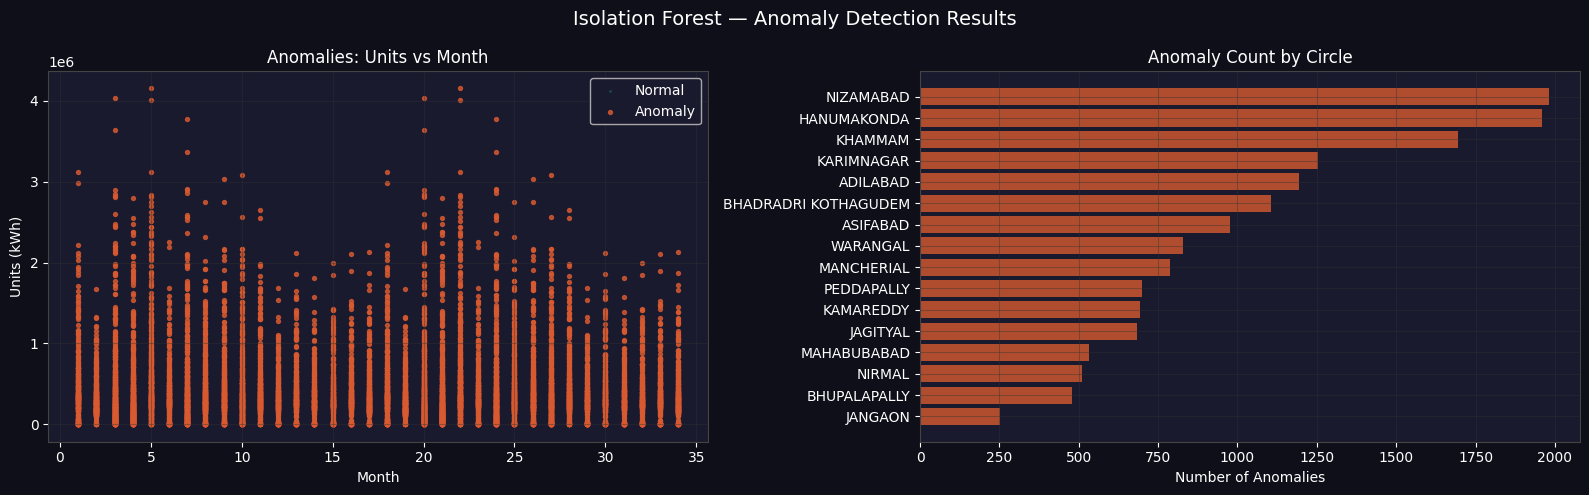

In [19]:
# ── Isolation Forest ─────────────────────────────────────────────
print('Training Isolation Forest...')
feats_iso = ['Units','Load','billing_ratio','avg_units_per_conn','load_factor']
X_iso = master[feats_iso].fillna(0)

scaler_iso = StandardScaler()
X_iso_scaled = scaler_iso.fit_transform(X_iso)

iso_model = IsolationForest(contamination=0.05, random_state=42, n_estimators=100)
master['anomaly_pred']  = iso_model.fit_predict(X_iso_scaled)
master['anomaly_score'] = iso_model.score_samples(X_iso_scaled)
master['is_anomaly']    = (master['anomaly_pred'] == -1).astype(int)

joblib.dump(iso_model,  'models/iso_forest.pkl')
joblib.dump(scaler_iso, 'models/scaler_iso.pkl')

print(f'✅ Anomalies detected: {master["is_anomaly"].sum():,} ({master["is_anomaly"].mean()*100:.1f}%)')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Isolation Forest — Anomaly Detection Results', color='white', fontsize=14)

normal_pts  = master[master['is_anomaly'] == 0]
anomaly_pts = master[master['is_anomaly'] == 1]

axes[0].scatter(normal_pts['month_num'],  normal_pts['Units'],  s=1, c='#1D9E75', alpha=0.3, label='Normal')
axes[0].scatter(anomaly_pts['month_num'], anomaly_pts['Units'], s=8, c='#D85A30', alpha=0.8, label='Anomaly')
axes[0].set_title('Anomalies: Units vs Month', color='white')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Units (kWh)')
axes[0].legend()

anom_by_circle = master.groupby('Circle')['is_anomaly'].sum().sort_values(ascending=True)
axes[1].barh(anom_by_circle.index, anom_by_circle.values, color='#D85A30', alpha=0.8)
axes[1].set_title('Anomaly Count by Circle', color='white')
axes[1].set_xlabel('Number of Anomalies')

plt.tight_layout()
plt.savefig('anomaly_results.png', dpi=150, bbox_inches='tight')
plt.show()


## Phase 5 — Disruption Prediction (Random Forest)

Training Random Forest...
Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     37013
  Disruption       1.00      1.00      1.00     25505

    accuracy                           1.00     62518
   macro avg       1.00      1.00      1.00     62518
weighted avg       1.00      1.00      1.00     62518

ROC-AUC Score: 1.0000


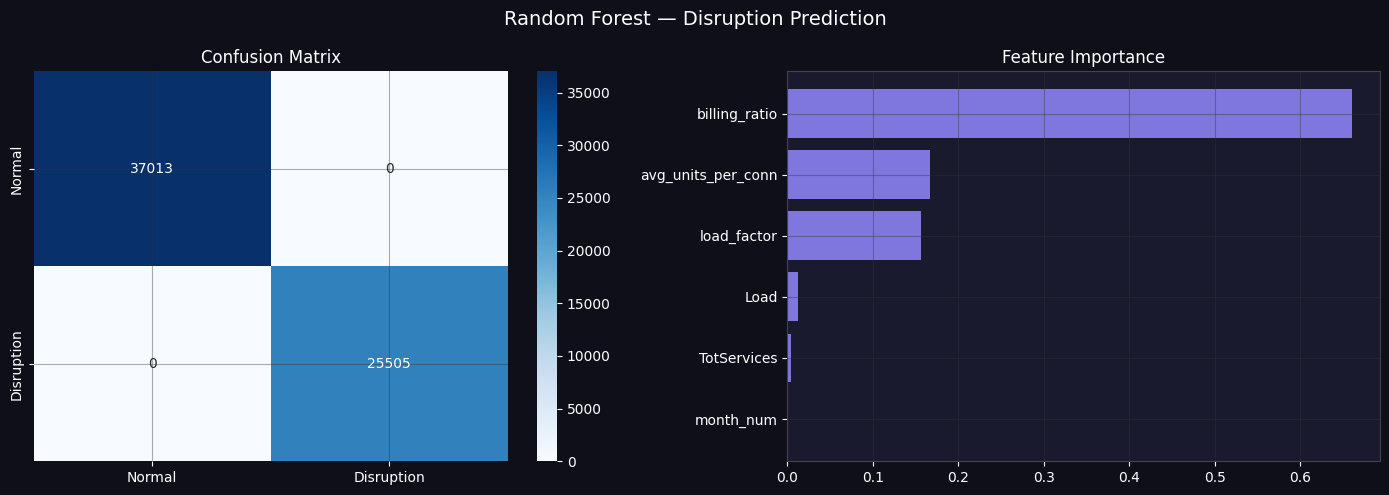

In [20]:
# ── Random Forest Classifier ─────────────────────────────────────
print('Training Random Forest...')
clf_feats = ['TotServices','avg_units_per_conn','load_factor','month_num','Load','billing_ratio']
X_clf = master[clf_feats].fillna(0)
y_clf = master['disruption']

X_tr, X_te, y_tr, y_te = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_tr, y_tr)
y_pred = rf_model.predict(X_te)
y_prob = rf_model.predict_proba(X_te)[:,1]

print('Classification Report:')
print(classification_report(y_te, y_pred, target_names=['Normal','Disruption']))
print(f'ROC-AUC Score: {roc_auc_score(y_te, y_prob):.4f}')

joblib.dump(rf_model, 'models/rf_disruption.pkl')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Forest — Disruption Prediction', color='white', fontsize=14)

# Confusion matrix
cm = confusion_matrix(y_te, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal','Disruption'], yticklabels=['Normal','Disruption'])
axes[0].set_title('Confusion Matrix', color='white')

# Feature importance
fi = pd.Series(rf_model.feature_importances_, index=clf_feats).sort_values()
axes[1].barh(fi.index, fi.values, color='#7F77DD')
axes[1].set_title('Feature Importance', color='white')

plt.tight_layout()
plt.savefig('rf_results.png', dpi=150, bbox_inches='tight')
plt.show()


## Phase 6 — Demand Forecasting (SARIMA + Prophet)

Training SARIMA...
6-Month Forecast:
  Month 35: 251.71 M kWh
  Month 36: 256.36 M kWh
  Month 37: 253.40 M kWh
  Month 38: 255.28 M kWh
  Month 39: 254.09 M kWh
  Month 40: 254.85 M kWh


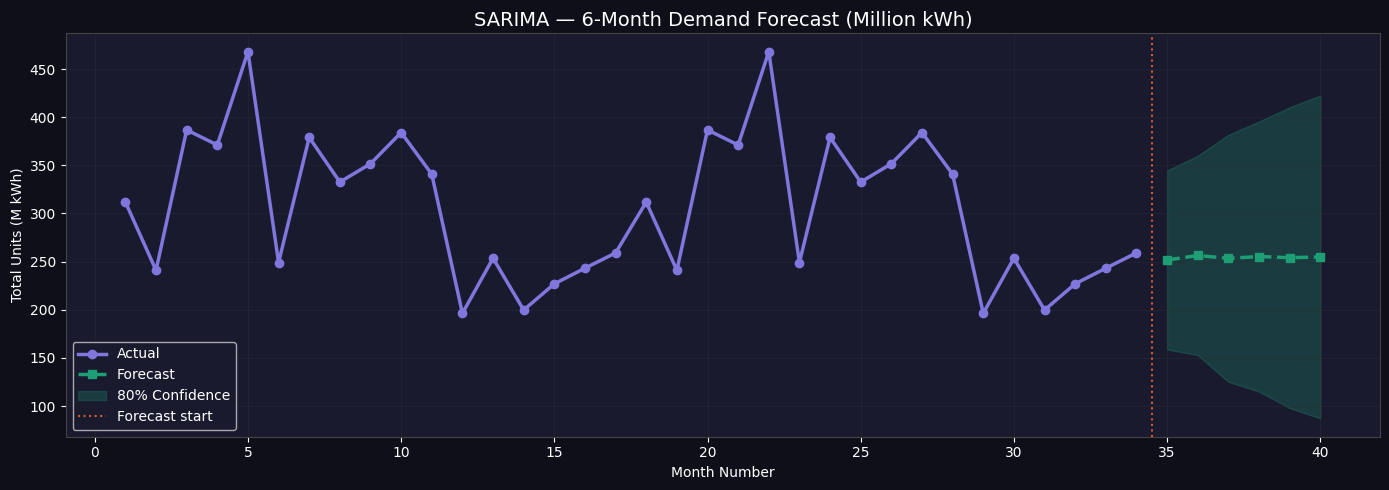

In [21]:
# ── SARIMA Demand Forecast ────────────────────────────────────────
print('Training SARIMA...')
monthly_ts = master.groupby('month_num')['Units'].sum()

sarima = SARIMAX(monthly_ts, order=(1,1,1), seasonal_order=(0,0,0,0),
                 enforce_stationarity=False, enforce_invertibility=False)
sarima_res = sarima.fit(disp=False)

forecast_steps = 6
forecast   = sarima_res.get_forecast(steps=forecast_steps)
fc_mean    = forecast.predicted_mean
fc_conf    = forecast.conf_int(alpha=0.2)

joblib.dump(sarima_res, 'models/sarima_model.pkl')

# Visualise
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0F0F1A')

months_hist = list(monthly_ts.index)
months_fc   = list(range(monthly_ts.index[-1]+1, monthly_ts.index[-1]+forecast_steps+1))

ax.plot(months_hist, monthly_ts.values/1e6, 'o-', color='#7F77DD', linewidth=2.5, label='Actual')
ax.plot(months_fc, fc_mean.values/1e6, 's--', color='#1D9E75', linewidth=2.5, label='Forecast')
ax.fill_between(months_fc, fc_conf.iloc[:,0]/1e6, fc_conf.iloc[:,1]/1e6,
                alpha=0.25, color='#1D9E75', label='80% Confidence')
ax.axvline(x=monthly_ts.index[-1]+0.5, color='#D85A30', linestyle=':', linewidth=1.5, label='Forecast start')
ax.set_title('SARIMA — 6-Month Demand Forecast (Million kWh)', color='white', fontsize=14)
ax.set_xlabel('Month Number'); ax.set_ylabel('Total Units (M kWh)')
ax.legend(); ax.grid(alpha=0.3)

print('6-Month Forecast:')
for m, v in zip(months_fc, fc_mean.values):
    print(f'  Month {m}: {v/1e6:.2f} M kWh')

plt.tight_layout()
plt.savefig('sarima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


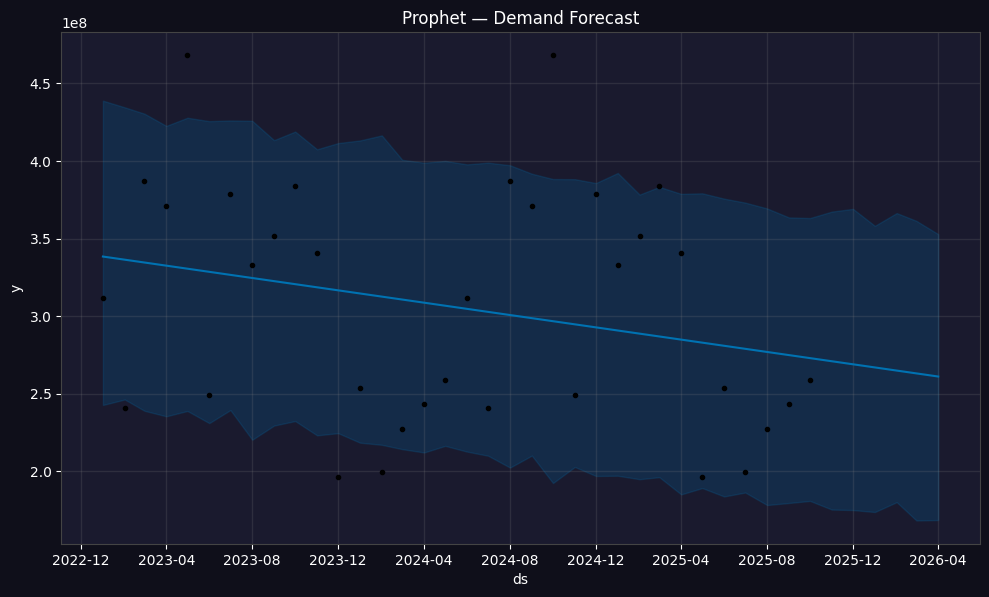

✅ Prophet forecast complete
           ds          yhat    yhat_lower    yhat_upper
34 2025-11-01  2.708559e+08  1.752242e+08  3.673582e+08
35 2025-12-01  2.688990e+08  1.749127e+08  3.691175e+08
36 2026-01-01  2.668768e+08  1.736454e+08  3.581669e+08
37 2026-02-01  2.648547e+08  1.800115e+08  3.664145e+08
38 2026-03-01  2.630282e+08  1.681995e+08  3.613836e+08
39 2026-04-01  2.610060e+08  1.684791e+08  3.527970e+08


In [22]:
# ── Prophet Forecast (optional — skip if not installed) ──────────
try:
    from prophet import Prophet
    df_prophet = monthly_ts.reset_index()
    df_prophet.columns = ['ds','y']
    df_prophet['ds'] = pd.date_range(start='2023-01-01', periods=len(df_prophet), freq='MS')

    m = Prophet(yearly_seasonality=False, weekly_seasonality=False,
                daily_seasonality=False, seasonality_mode='additive')
    m.fit(df_prophet)
    future   = m.make_future_dataframe(periods=6, freq='MS')
    forecast = m.predict(future)

    fig2 = m.plot(forecast)
    fig2.patch.set_facecolor('#0F0F1A')
    plt.title('Prophet — Demand Forecast', color='white')
    plt.savefig('prophet_forecast.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Prophet forecast complete')
    print(forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(6).to_string())
except ImportError:
    print('Prophet not installed — run: pip install prophet')


## Phase 7 — Circle Clustering (KMeans)

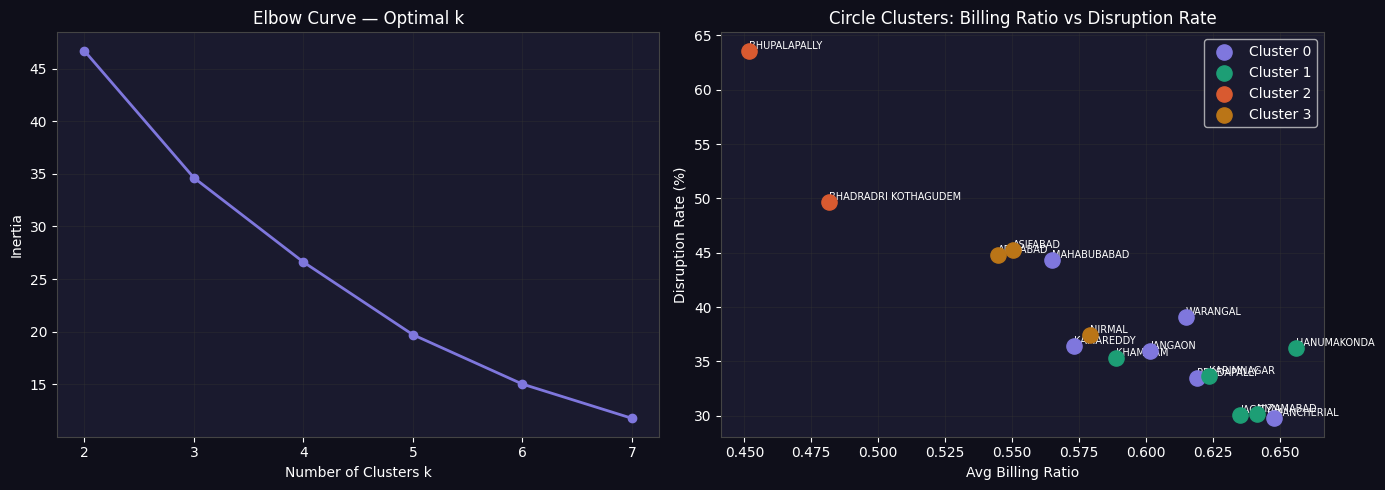


Cluster Summary:
         avg_billing_ratio  disruption_rate  avg_units
cluster                                               
0                    0.604            0.365  32480.292
1                    0.629            0.331  60098.977
2                    0.467            0.566  17840.099
3                    0.558            0.425  17395.108


In [24]:
# ── KMeans Clustering ────────────────────────────────────────────
circle_agg = master.groupby('Circle').agg(
    avg_units        = ('Units','mean'),
    total_units      = ('Units','sum'),
    avg_connections  = ('TotServices','mean'),
    avg_billing_ratio= ('billing_ratio','mean'),
    avg_load_factor  = ('load_factor','mean'),
    disruption_rate  = ('disruption','mean'),
).dropna()

scaler_km = StandardScaler()
X_km = scaler_km.fit_transform(circle_agg)

# Elbow method
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_km).inertia_ for k in range(2,8)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(2,8), inertias, 'o-', color='#7F77DD', linewidth=2)
axes[0].set_title('Elbow Curve — Optimal k', color='white')
axes[0].set_xlabel('Number of Clusters k'); axes[0].set_ylabel('Inertia')

# Apply k=4
km = KMeans(n_clusters=4, random_state=42, n_init=10)
circle_agg['cluster'] = km.fit_predict(X_km)
joblib.dump(km, 'models/kmeans.pkl')

cluster_colors = ['#7F77DD','#1D9E75','#D85A30','#BA7517']
for cl in range(4):
    subset = circle_agg[circle_agg['cluster']==cl]
    axes[1].scatter(subset['avg_billing_ratio'], subset['disruption_rate']*100,
                    s=120, c=cluster_colors[cl], label=f'Cluster {cl}', zorder=5)
    for idx, row in subset.iterrows():
        axes[1].annotate(idx, (row['avg_billing_ratio'], row['disruption_rate']*100),
                         fontsize=7, color='white', ha='left', va='bottom')

axes[1].set_title('Circle Clusters: Billing Ratio vs Disruption Rate', color='white')
axes[1].set_xlabel('Avg Billing Ratio'); axes[1].set_ylabel('Disruption Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCluster Summary:')
print(circle_agg.groupby('cluster')[['avg_billing_ratio','disruption_rate','avg_units']].mean().round(3))


## Phase 8 — Model Evaluation Summary

In [25]:
# ── Evaluation Summary ───────────────────────────────────────────
print('='*60)
print('GRIDMIND AI — MODEL EVALUATION SUMMARY')
print('='*60)

# Random Forest
y_pred_rf   = rf_model.predict(X_te)
y_prob_rf   = rf_model.predict_proba(X_te)[:,1]
print('\n1. RANDOM FOREST — Disruption Prediction')
print(f'   Accuracy : {(y_pred_rf == y_te).mean()*100:.2f}%')
print(f'   ROC-AUC  : {roc_auc_score(y_te, y_prob_rf):.4f}')

# Isolation Forest
print('\n2. ISOLATION FOREST — Anomaly Detection')
print(f'   Anomalies detected  : {master["is_anomaly"].sum():,} ({master["is_anomaly"].mean()*100:.1f}%)')
print(f'   Normal points       : {(master["is_anomaly"]==0).sum():,}')

# SARIMA
in_sample = sarima_res.fittedvalues
mae_sarima = mean_absolute_error(monthly_ts, in_sample)
rmse_sarima = np.sqrt(mean_squared_error(monthly_ts, in_sample))
mape_sarima = np.mean(np.abs((monthly_ts - in_sample)/monthly_ts))*100
print('\n3. SARIMA — Demand Forecasting')
print(f'   MAE  : {mae_sarima/1e6:.3f} M kWh')
print(f'   RMSE : {rmse_sarima/1e6:.3f} M kWh')
print(f'   MAPE : {mape_sarima:.2f}%')

# KMeans
sil = silhouette_score(X_km, km.labels_)
print('\n4. KMEANS — Circle Clustering')
print(f'   Silhouette Score : {sil:.4f}')
print(f'   Clusters formed  : {km.n_clusters}')

print('\n All models evaluated successfully')
print("\nSaved models:")
for f in os.listdir('models'):
    print(f'  models/{f}')


GRIDMIND AI — MODEL EVALUATION SUMMARY

1. RANDOM FOREST — Disruption Prediction
   Accuracy : 100.00%
   ROC-AUC  : 1.0000

2. ISOLATION FOREST — Anomaly Detection
   Anomalies detected  : 15,630 (5.0%)
   Normal points       : 296,958

3. SARIMA — Demand Forecasting
   MAE  : 60.573 M kWh
   RMSE : 89.298 M kWh
   MAPE : 21.43%

4. KMEANS — Circle Clustering
   Silhouette Score : 0.2610
   Clusters formed  : 4

 All models evaluated successfully

Saved models:
  models/rf_disruption.pkl
  models/sarima_model.pkl
  models/kmeans.pkl
  models/iso_forest.pkl
  models/scaler_iso.pkl
